# Práctico 1: EDA y Visualización

Esta notebook traduce las consignas de `practico/practico_1.md` a un flujo de trabajo ejecutable y ordenado.

## Objetivo
Explorar los datos de adopción de IA para: 
1. Entender su estructura y calidad.
2. Describir variables clave de manera univariada.
3. Analizar relaciones bivariadas relevantes para el proyecto.
4. Formular hipóesis de investigación para los próximos prácticos.

## 1) Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2) Carga de datos

Esta celda carga los tres archivos provistos en `data/raw/`:
- `ai_company_adoption.csv`
- `ai_industry_summary.csv`
- `country_ai_index.csv`

Usamos rutas relativas desde la carpeta `notebook/` para facilitar portabilidad del proyecto.
Finalmente, mostramos las dimensiones iniciales para validar que la lectura fue correcta.

In [2]:
company = pd.read_csv('../data/raw/ai_company_adoption.csv')
industry = pd.read_csv('../data/raw/ai_industry_summary.csv')
country = pd.read_csv('../data/raw/country_ai_index.csv')

print('company:', company.shape)
print('industry:', industry.shape)
print('country:', country.shape)

company: (150025, 43)
industry: (9, 8)
country: (30, 8)


In [ ]:
# Chequear datos duplicados


In [5]:
company.info()

<class 'pandas.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  str    
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  str    
 4   country                      150024 non-null  str    
 5   region                       150024 non-null  str    
 6   industry                     147772 non-null  str    
 7   company_size                 147774 non-null  str    
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            150024 non-null  str    
 13  ai_adoptio

In [17]:
company['ai_adoption_stage'].value_counts()

ai_adoption_stage
partial    78816
pilot      64323
none        5199
full        1686
Name: count, dtype: int64

In [6]:
industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      str    
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), str(1)
memory usage: 708.0 bytes


In [7]:
country.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     str    
 1   region                      30 non-null     str    
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     str    
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.0 KB


En base al análisis rápido realizado, podemos concluir que las bases están compuestas de la siguiente manera:
`company`: microdatos a nivel empresa/respuesta (archivo principal del análisis).
`industry`: resumen agregado por industria (útil para contraste).
`country`: contexto país (madurez digital, I+D, políticas, etc.).


## 3) Descripción general del dataset

### ¿Cuántos registros y variables tiene cada archivo?
La celda siguiente construye una tabla-resumen con filas (registros), columnas (variables) y cantidad de variables numéricas/categóricas por dataset.

### ¿Qué tipo de variables hay?
Distinguimos tipos en dos grupos prácticos:
- Numéricas (`number`): continuas o discretas para métricas/cantidades.
- Categóricas (`object`, `category`): etiquetas de país, industria, etapa de adopción, etc.

Esto permite entender qué tipo de análisis y gráficos corresponde aplicar después.

In [3]:
summary = pd.DataFrame({
    'dataset': ['company', 'industry', 'country'],
    'rows': [len(company), len(industry), len(country)],
    'columns': [company.shape[1], industry.shape[1], country.shape[1]],
    'numeric_vars': [company.select_dtypes(include='number').shape[1], industry.select_dtypes(include='number').shape[1], country.select_dtypes(include='number').shape[1]],
    'categorical_vars': [company.select_dtypes(exclude='number').shape[1], industry.select_dtypes(exclude='number').shape[1], country.select_dtypes(exclude='number').shape[1]],
})
summary

,dataset,rows,columns,numeric_vars,categorical_vars
0,company,150025,43,29,14
1,industry,9,8,7,1
2,country,30,8,5,3


### ¿Qué representa cada archivo y cómo se relacionan entre sí?

La celda siguiente verifica claves y relaciones lógicas:
- `company` se puede agregar por `industry` para comparar contra la tabla `industry`.
- `company` se puede agregar por `country` para conectar con la tabla `country`.

In [4]:
print('Industrias en company:', company['industry'].nunique())
print('Industrias en industry:', industry['industry'].nunique())
print('Paises en company:', company['country'].nunique())
print('Paises en country:', country['country'].nunique())

print('Industrias de industry que faltan en company:', set(industry['industry']) - set(company['industry'].dropna()))
print('Paises de country que faltan en company:', set(country['country']) - set(company['country'].dropna()))

Industrias en company: 9
Industrias en industry: 9
Paises en company: 30
Paises en country: 30
Industrias de industry que faltan en company: set()
Paises de country que faltan en company: set()


Estas parecen buenas noticias! Todas las observaciones que están en las tablas agregadas también se encuentra en la tabla de compañías.

## 4) Análisis univariado (5 variables relevantes)

A continuación analizamos al menos cinco variables del archivo principal `company`:
1. `ai_adoption_rate` (numérica)
2. `ai_maturity_score` (numérica)
3. `productivity_change_percent` (numérica)
4. `industry` (categórica)
5. `company_size` (categórica)

Para las numéricas mostramos **histograma + boxplot** (forma, dispersión, asimetría y outliers).
Para categóricas mostramos **frecuencias relativas** (composición).

Además de los gráficos, cada celda imprime estadíisticas básicas para respaldar la interpretación.


ai_adoption_rate
count    147776.000000
mean         36.431407
std          15.418903
min        -137.995275
25%          26.420000
50%          36.330000
75%          46.230000
max         210.119890
Name: ai_adoption_rate, dtype: float64


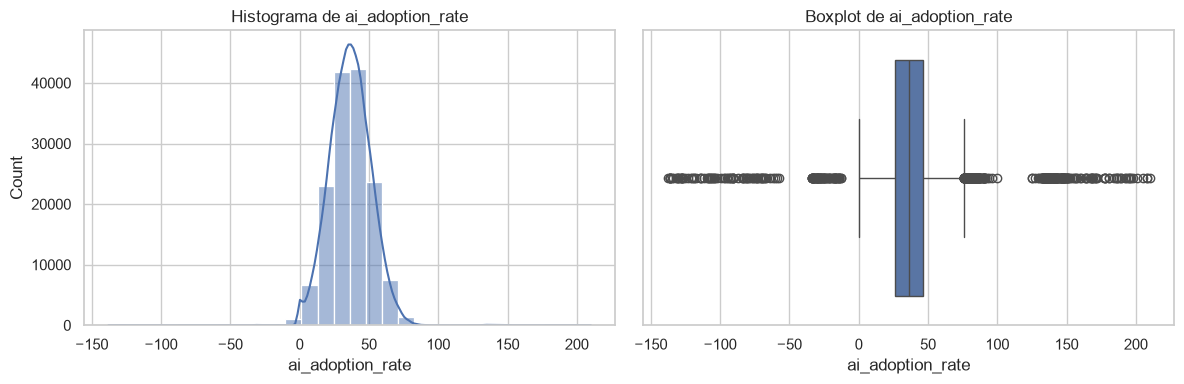


ai_maturity_score
count    150025.000000
mean          0.344678
std           0.133817
min           0.000000
25%           0.250000
50%           0.341000
75%           0.435000
max           0.904000
Name: ai_maturity_score, dtype: float64


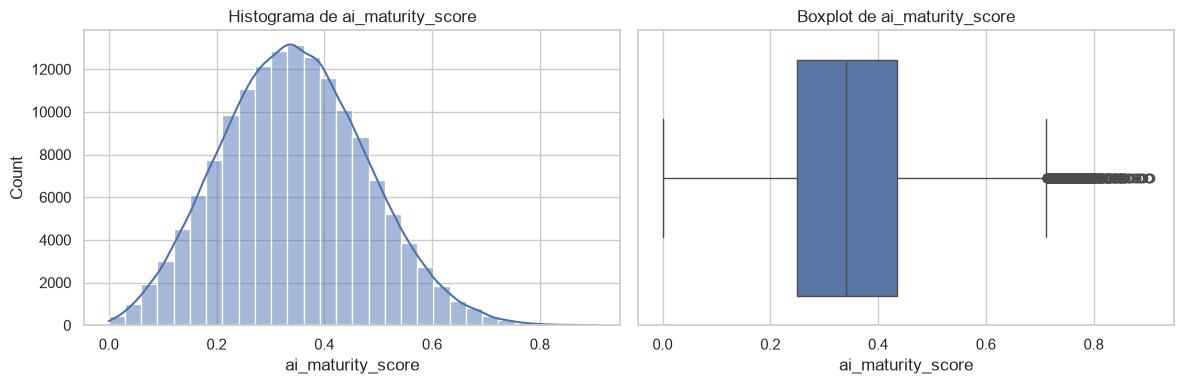


productivity_change_percent
count    150025.000000
mean          9.310881
std           6.368602
min         -57.053637
25%           5.060000
50%           9.060000
75%          13.130000
max         119.200258
Name: productivity_change_percent, dtype: float64


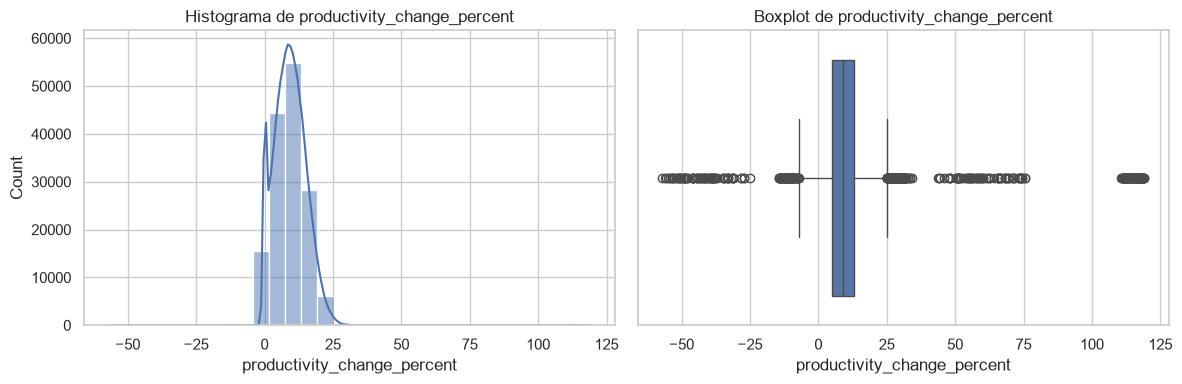

In [8]:
num_vars = ['ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent']

for col in num_vars:
    print(f'\n{col}')
    print(company[col].describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(company[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')

    sns.boxplot(x=company[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

Analizar productivy_change_opercent por aiadoption_stage



Hay algo raro con la métrica `ai_adoption_rate`: existen tasas superiores al 100% y también inferiores al 0%. Lo mejor sería limpiar esa variable de valores atípicos.

Con respecto al `ai_maturity_score`, parece ser una métrica que va entre 0 y 1. Tiene una distribución normal con una ligera asimetría hacia la derecha. 

El `productivity_change_percent` también muestra valores negativos y mayores al 100%. Sin embargo, esto podría explicarse por una disminución, o un aumento superior al 100% (más del doble) de la productividad luego de la adopción de IA.

La siguiente celda cubre dos variables categóricas con mayor impacto interpretativo:

- `industry`: permite identificar sectores más representados y contextualizar comparaciones.
- `company_size`: muestra composición por tamaño empresarial, importante porque puede sesgar niveles de inversión/adopción.

Usamos frecuencias normalizadas (`value_counts(normalize=True)`) para que la lectura sea porcentual y comparable.


Distribucion relativa de industry (top 10):
industry
Technology       13.87
Finance          13.24
Healthcare       12.23
Manufacturing    11.51
Retail           10.76
Agriculture      10.22
Education         9.97
Logistics         8.50
Consulting        8.20
NaN               1.50
Name: proportion, dtype: float64


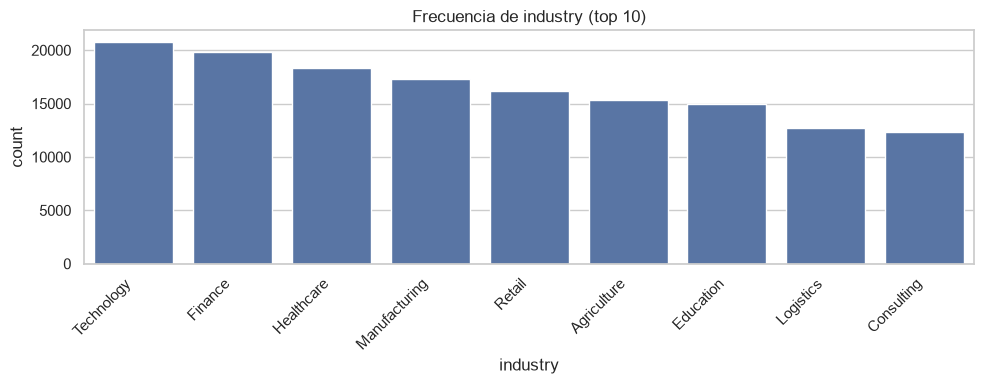


Distribucion relativa de company_size (top 10):
company_size
SME           41.96
Startup       37.23
Enterprise    19.31
NaN            1.50
Name: proportion, dtype: float64


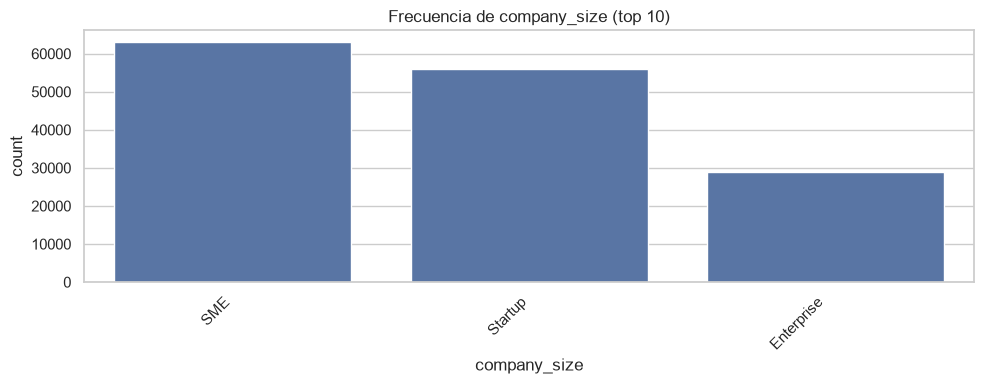

In [9]:
for col in ['industry', 'company_size']:
    dist = company[col].value_counts(dropna=False, normalize=True).head(10)
    print(f'\nDistribucion relativa de {col} (top 10):')
    print((dist * 100).round(2))

    plt.figure(figsize=(10, 4))
    sns.countplot(data=company, x=col, order=company[col].value_counts().index[:10])
    plt.title(f'Frecuencia de {col} (top 10)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5) Análisis bivariado y comparaciones (3 relaciones)

Aquí exploramos tres relaciones alineadas con la consigna:

1. **Adopción de IA por industria**
   - Pregunta: qué sectores muestran mayor/menor tasa de adopción?
   - Gráfico: boxplot por industria para observar nivel típico y variabilidad.

2. **Inversión en IA vs cambio de productividad**
   - Pregunta: mayor inversión por empleado se asocia con mayor productividad?
   - Gráfico: dispersión con tendencia lineal (`regplot`).

3. **Diferencias entre regiones y vínculo país-madurez digital**
   - Preguntas: hay brechas de adopción por región? la madurez digital del país se relaciona con adopción promedio?
   - Gráficos: barplot por región + dispersión entre `digital_maturity_index` y adopción promedio por país.

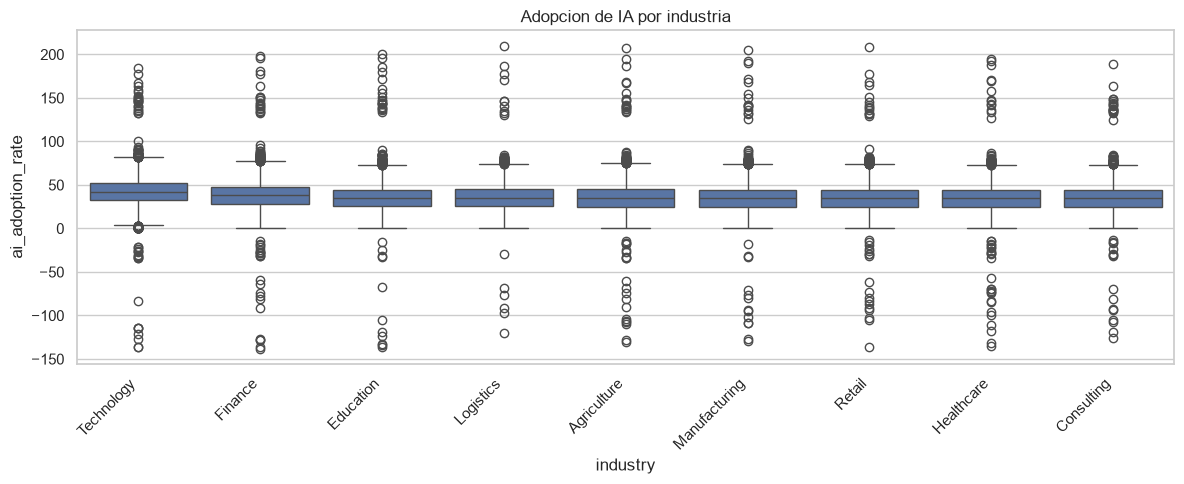

industry
Technology       42.50
Finance          38.33
Education        35.33
Logistics        35.30
Agriculture      35.22
Manufacturing    34.76
Retail           34.73
Healthcare       34.57
Consulting       34.57
Name: ai_adoption_rate, dtype: float64

In [10]:
order_industry = company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=company, x='industry', y='ai_adoption_rate', order=order_industry)
plt.title('Adopcion de IA por industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)

No parece haber diferencias significativas entre las industrias respecto de su tasa de adopción media.

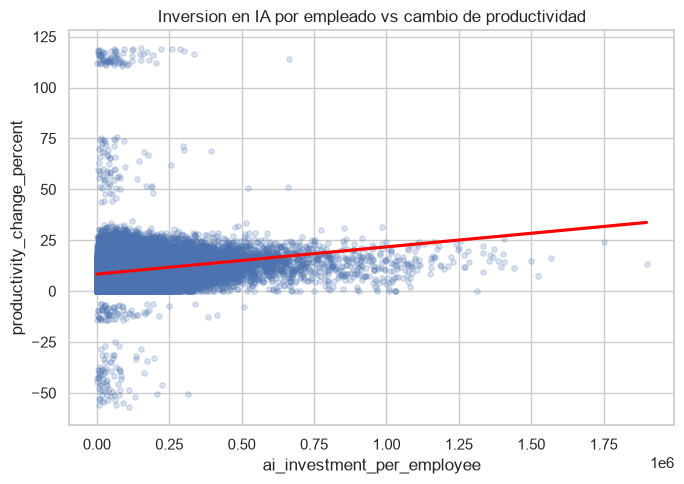

,ai_investment_per_employee,productivity_change_percent
ai_investment_per_employee,1.000,0.187
productivity_change_percent,0.187,1.000


In [14]:
# Limpiamos las variables de valores negativos y nulos para el análisis de correlación
company_clean = company[(company['ai_investment_per_employee'] >= 0)].dropna(subset=['productivity_change_percent', 'ai_investment_per_employee'])
plt.figure(figsize=(7, 5))
sns.regplot(data=company_clean, x='ai_investment_per_employee', y='productivity_change_percent', scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'})
plt.title('Inversion en IA por empleado vs cambio de productividad')
plt.tight_layout()
plt.show()

company_clean[['ai_investment_per_employee', 'productivity_change_percent']].corr().round(3)

La correlación entre las variables es muy baja ($R^2=0.187$) y el gráfico de dispersión da cuenta de que no hay una relación muy clara entre las variables: incluso niveles bajos de inversión están asociados a cambios grandes en la productividad, mientras que niveles altos de inversión no parecen motorizar grandes cambios. 

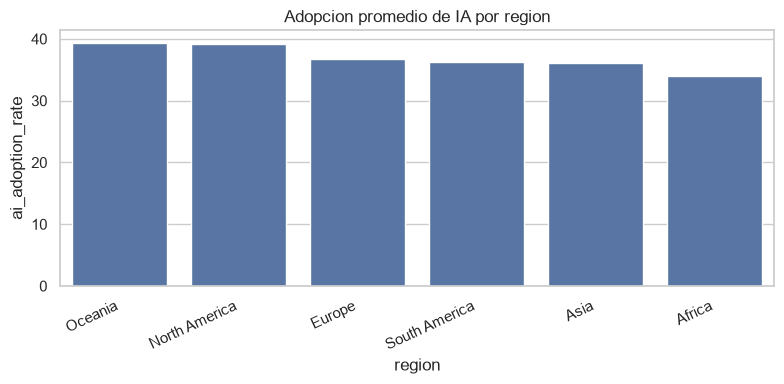

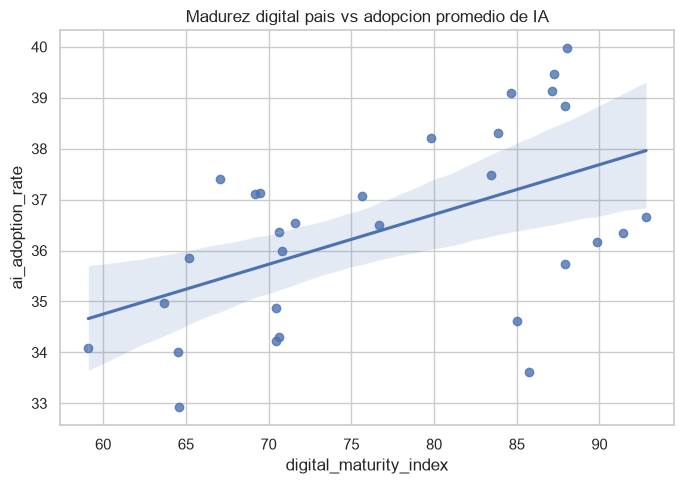

,digital_maturity_index,ai_adoption_rate
digital_maturity_index,1.000,0.521
ai_adoption_rate,0.521,1.000


In [15]:
region_mean = company.groupby('region', as_index=False)['ai_adoption_rate'].mean().sort_values('ai_adoption_rate', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=region_mean, x='region', y='ai_adoption_rate')
plt.title('Adopcion promedio de IA por region')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

country_adoption = company.groupby('country', as_index=False)['ai_adoption_rate'].mean()
country_merged = country_adoption.merge(country[['country', 'digital_maturity_index']], on='country', how='left')

plt.figure(figsize=(7, 5))
sns.regplot(data=country_merged, x='digital_maturity_index', y='ai_adoption_rate')
plt.title('Madurez digital pais vs adopcion promedio de IA')
plt.tight_layout()
plt.show()

country_merged[['digital_maturity_index', 'ai_adoption_rate']].corr().round(3)